In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import TensorDataset, DataLoader
import gpytorch
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.data_loader import load_cmapss_data
from src.utils.metrics import phm_scoring_function
from src.models.train_dkl_svgp import train_dkl_autoencoder

# graphic settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: cpu


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'

def compare_cmapss_dataset(dataset_name, dkl_epochs=30):
    print(f"\n\n{'='*60}")
    print(f"🚀 INIZIO VALUTAZIONE DATASET: {dataset_name}")
    print(f"{'='*60}")

    # 1. Load data
    df_train = load_cmapss_data(str(DATA_DIR / f'train_{dataset_name}.txt'))
    df_test = load_cmapss_data(str(DATA_DIR / f'test_{dataset_name}.txt'), str(DATA_DIR / f'RUL_{dataset_name}.txt'))

    # 2. Feature Selection (Settings + Sensors)
    candidate_cols = ['setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
    
    # Variance calculation
    variances = df_train[candidate_cols].var()
    
    # Delete columns with zero variance (completely flat)
    dead_cols = variances[variances == 0.0].index.tolist()
    features = [c for c in candidate_cols if c not in dead_cols]
    
    print(f"Excluded columns (Zero Variance): {dead_cols if dead_cols else 'None'}")
    print(f"Active features (Settings + Sensors): {len(features)}")


    # 3. RUL Clipping
    MAX_RUL = 125
    df_train['RUL'] = df_train['RUL'].clip(upper=MAX_RUL)
    y_train = df_train['RUL'].values
    y_test_true = df_test['RUL'].values 

    # 4. Standardization (Fit on train)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(df_train[features].values)
    X_test_scaled = scaler.transform(df_test[features].values)

    # 5. Extracting Last Cycles (Standard NASA for fair metrics)
    last_cycle_indices = df_test.groupby('unit_nr').tail(1).index
    X_test_last = X_test_scaled[last_cycle_indices]
    y_test_last = y_test_true[last_cycle_indices]

    # --- RANDOM FOREST ---
    print("🌲 Training Baseline (Random Forest)...")
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_model.fit(X_train_scaled, y_train)

    rf_preds_last = rf_model.predict(X_test_last)
    
    # Metrics RF
    rf_rmse = np.sqrt(mean_squared_error(y_test_last, rf_preds_last))
    rf_mae = mean_absolute_error(y_test_last, rf_preds_last)
    rf_r2 = r2_score(y_test_last, rf_preds_last)
    rf_score = phm_scoring_function(rf_preds_last, y_test_last)
    
    rf_errors = rf_preds_last - y_test_last
    rf_late_count = np.sum(rf_errors > 0)
    rf_early_count = np.sum(rf_errors < 0)

    rf_preds_all = rf_model.predict(X_test_scaled)

    # --- DKL + SVGP ---
    print(f"🧠 Training Proposed Model (DKL+SVGP - {dkl_epochs} epoche)...")
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

    dkl_model, likelihood = train_dkl_autoencoder(
        train_loader=train_loader,
        input_dim=len(features),
        latent_dim=4,
        num_inducing=100,
        epochs=dkl_epochs,
        lr=0.001,
        seed=42
    )

    dkl_model.eval()
    likelihood.eval()

    X_test_last_tensor = torch.tensor(X_test_last, dtype=torch.float32).to(device)
    X_test_all_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred_dist_last = likelihood(dkl_model(X_test_last_tensor))
        dkl_preds_last = pred_dist_last.mean.cpu().numpy()
        
        # Metriche DKL
        dkl_rmse = np.sqrt(mean_squared_error(y_test_last, dkl_preds_last))
        dkl_mae = mean_absolute_error(y_test_last, dkl_preds_last)
        dkl_r2 = r2_score(y_test_last, dkl_preds_last)
        dkl_score = phm_scoring_function(dkl_preds_last, y_test_last)
        
        dkl_errors = dkl_preds_last - y_test_last
        dkl_late_count = np.sum(dkl_errors > 0)
        dkl_early_count = np.sum(dkl_errors < 0)

        pred_dist_all = likelihood(dkl_model(X_test_all_tensor))
        dkl_preds_all = pred_dist_all.mean.cpu().numpy()
        lower_all, upper_all = pred_dist_all.confidence_region()
        dkl_lower_all = lower_all.cpu().numpy()
        dkl_upper_all = upper_all.cpu().numpy()

    print("\n📊 --- REPORT METRICHE FINALI ---")
    print(f"{'Metrica':<20} | {'Random Forest':<15} | {'DKL+SVGP':<15}")
    print("-" * 55)
    print(f"{'RMSE (Cicli)':<20} | {rf_rmse:<15.2f} | {dkl_rmse:<15.2f}")
    print(f"{'MAE (Cicli)':<20} | {rf_mae:<15.2f} | {dkl_mae:<15.2f}")
    print(f"{'R-Squared (R2)':<20} | {rf_r2:<15.3f} | {dkl_r2:<15.3f}")
    print(f"{'C-MAPSS Score':<20} | {rf_score:<15.0f} | {dkl_score:<15.0f}")
    print(f"{'Late Preds (Guasti)':<20} | {rf_late_count:<15} | {dkl_late_count:<15}")
    print(f"{'Early Preds (Sicuri)':<20} | {rf_early_count:<15} | {dkl_early_count:<15}")
    print("-" * 55)

    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.5])

    ax_rmse = fig.add_subplot(gs[0, 0])
    ax_score = fig.add_subplot(gs[0, 1])
    ax_traj = fig.add_subplot(gs[1, :]) 

    models_labels = ['Baseline\n(Random Forest)', 'Proposed\n(DKL + SVGP)']
    palette = ['#8c564b', '#1f77b4']

    # Plot 1: RMSE Barplot
    sns.barplot(x=models_labels, y=[rf_rmse, dkl_rmse], ax=ax_rmse, palette=palette)
    ax_rmse.set_title(f'[{dataset_name}] RMSE on Final Cycle', fontsize=14, fontweight='bold')
    ax_rmse.set_ylabel('RMSE (Cycles)')
    for i, v in enumerate([rf_rmse, dkl_rmse]):
        ax_rmse.text(i, v + (max(rf_rmse, dkl_rmse)*0.02), f"{v:.2f}", ha='center', fontsize=12)

    # Plot 2: Score Barplot
    sns.barplot(x=models_labels, y=[rf_score, dkl_score], ax=ax_score, palette=palette)
    ax_score.set_title(f'[{dataset_name}] C-MAPSS Score on Final Cycle', fontsize=14, fontweight='bold')
    ax_score.set_ylabel('Penalty Score')
    for i, v in enumerate([rf_score, dkl_score]):
        ax_score.text(i, v + (max(rf_score, dkl_score)*0.02), f"{v:,.0f}", ha='center', fontsize=12)

    # Plot 3: Trajectory of Engine
    first_engine_id = df_test['unit_nr'].unique()[0]
    eng_indices = df_test[df_test['unit_nr'] == first_engine_id].index
    y_true_eng = y_test_true[eng_indices]
    cycles = range(len(y_true_eng))

    ax_traj.plot(cycles, y_true_eng, label='True RUL', color='black', linewidth=3)
    ax_traj.plot(cycles, rf_preds_all[eng_indices], label='Random Forest Mean', color='#8c564b', linestyle='-.', linewidth=2.5)
    ax_traj.plot(cycles, dkl_preds_all[eng_indices], label='DKL+SVGP Mean', color='#1f77b4', linestyle='--', linewidth=2.5)
    ax_traj.fill_between(cycles, dkl_lower_all[eng_indices], dkl_upper_all[eng_indices], color='#1f77b4', alpha=0.2, label='DKL+SVGP (95% CI)')

    ax_traj.set_title(f'[{dataset_name}] Prediction Trajectories - Test Engine #{first_engine_id}', fontsize=16, fontweight='bold', pad=15)
    ax_traj.set_xlabel('Operational Cycle', fontsize=12)
    ax_traj.set_ylabel('Remaining Useful Life (RUL)', fontsize=12)
    ax_traj.legend(fontsize=12, loc='upper right')
    ax_traj.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {'rf_rmse': rf_rmse, 'dkl_rmse': dkl_rmse, 'rf_score': rf_score, 'dkl_score': dkl_score}



🚀 INIZIO VALUTAZIONE DATASET: FD001
Colonne escluse (Varianza 0): ['setting_3', 's_1', 's_10', 's_18', 's_19']
Features attive (Settings + Sensori) fornite ai modelli: 19
🌲 Addestramento Baseline (Random Forest)...
🧠 Addestramento Proposed Model (DKL+SVGP - 100 epoche)...
--- Starting DKL Autoencoder SVGP Training (100 Epochs) ---
Epoch 01 | MLL Loss: 1326702.3588 | Recon Loss: 1.0561
Epoch 02 | MLL Loss: 442064.2751 | Recon Loss: 0.8448
Epoch 03 | MLL Loss: 270580.0826 | Recon Loss: 0.6896
Epoch 04 | MLL Loss: 193167.7678 | Recon Loss: 0.5801
Epoch 05 | MLL Loss: 151890.9289 | Recon Loss: 0.5024
Epoch 06 | MLL Loss: 122249.7633 | Recon Loss: 0.4473
Epoch 07 | MLL Loss: 103607.5206 | Recon Loss: 0.4096
Epoch 08 | MLL Loss: 87797.0193 | Recon Loss: 0.3841
Epoch 09 | MLL Loss: 76076.3784 | Recon Loss: 0.3672
Epoch 10 | MLL Loss: 68042.4349 | Recon Loss: 0.3556
Epoch 11 | MLL Loss: 59612.6333 | Recon Loss: 0.3466
Epoch 12 | MLL Loss: 54142.4499 | Recon Loss: 0.3399
Epoch 13 | MLL Loss: 

/tmp/ipykernel_1246398/3016407815.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_labels, y=[rf_rmse, dkl_rmse], ax=ax_rmse, palette=palette)
/tmp/ipykernel_1246398/3016407815.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_labels, y=[rf_score, dkl_score], ax=ax_score, palette=palette)


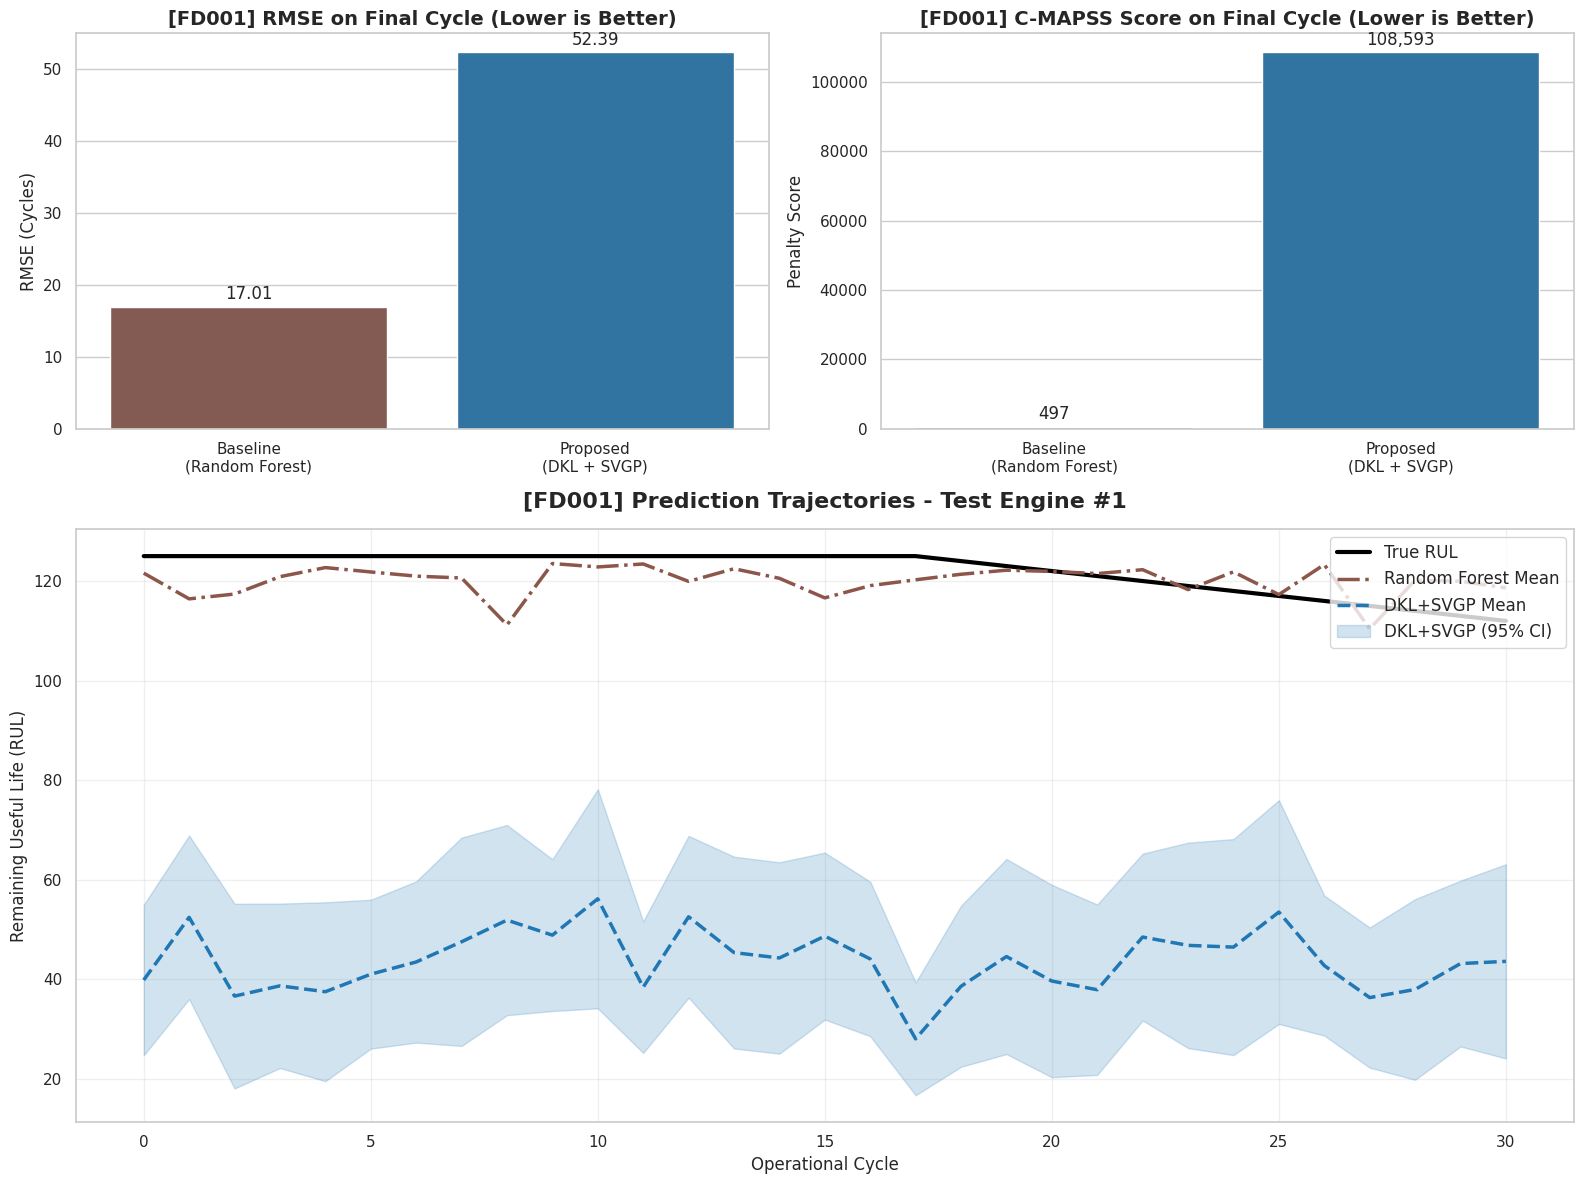



🚀 INIZIO VALUTAZIONE DATASET: FD002
Colonne escluse (Varianza 0): Nessuna
Features attive (Settings + Sensori) fornite ai modelli: 24
🌲 Addestramento Baseline (Random Forest)...
🧠 Addestramento Proposed Model (DKL+SVGP - 100 epoche)...
--- Starting DKL Autoencoder SVGP Training (100 Epochs) ---
Epoch 01 | MLL Loss: 1150119.2625 | Recon Loss: 0.7033
Epoch 02 | MLL Loss: 324529.7580 | Recon Loss: 0.3530
Epoch 03 | MLL Loss: 189324.0608 | Recon Loss: 0.2004
Epoch 04 | MLL Loss: 117128.2102 | Recon Loss: 0.2011
Epoch 05 | MLL Loss: 79926.0245 | Recon Loss: 0.2018
Epoch 06 | MLL Loss: 60363.7712 | Recon Loss: 0.1847
Epoch 07 | MLL Loss: 46918.8662 | Recon Loss: 0.1772
Epoch 08 | MLL Loss: 37295.9171 | Recon Loss: 0.1805
Epoch 09 | MLL Loss: 30411.5559 | Recon Loss: 0.1735
Epoch 10 | MLL Loss: 25287.6436 | Recon Loss: 0.1702
Epoch 11 | MLL Loss: 21349.8199 | Recon Loss: 0.1657
Epoch 12 | MLL Loss: 18469.5192 | Recon Loss: 0.1689
Epoch 13 | MLL Loss: 15726.3389 | Recon Loss: 0.1774
Epoch 14

/tmp/ipykernel_1246398/3016407815.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_labels, y=[rf_rmse, dkl_rmse], ax=ax_rmse, palette=palette)
/tmp/ipykernel_1246398/3016407815.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_labels, y=[rf_score, dkl_score], ax=ax_score, palette=palette)


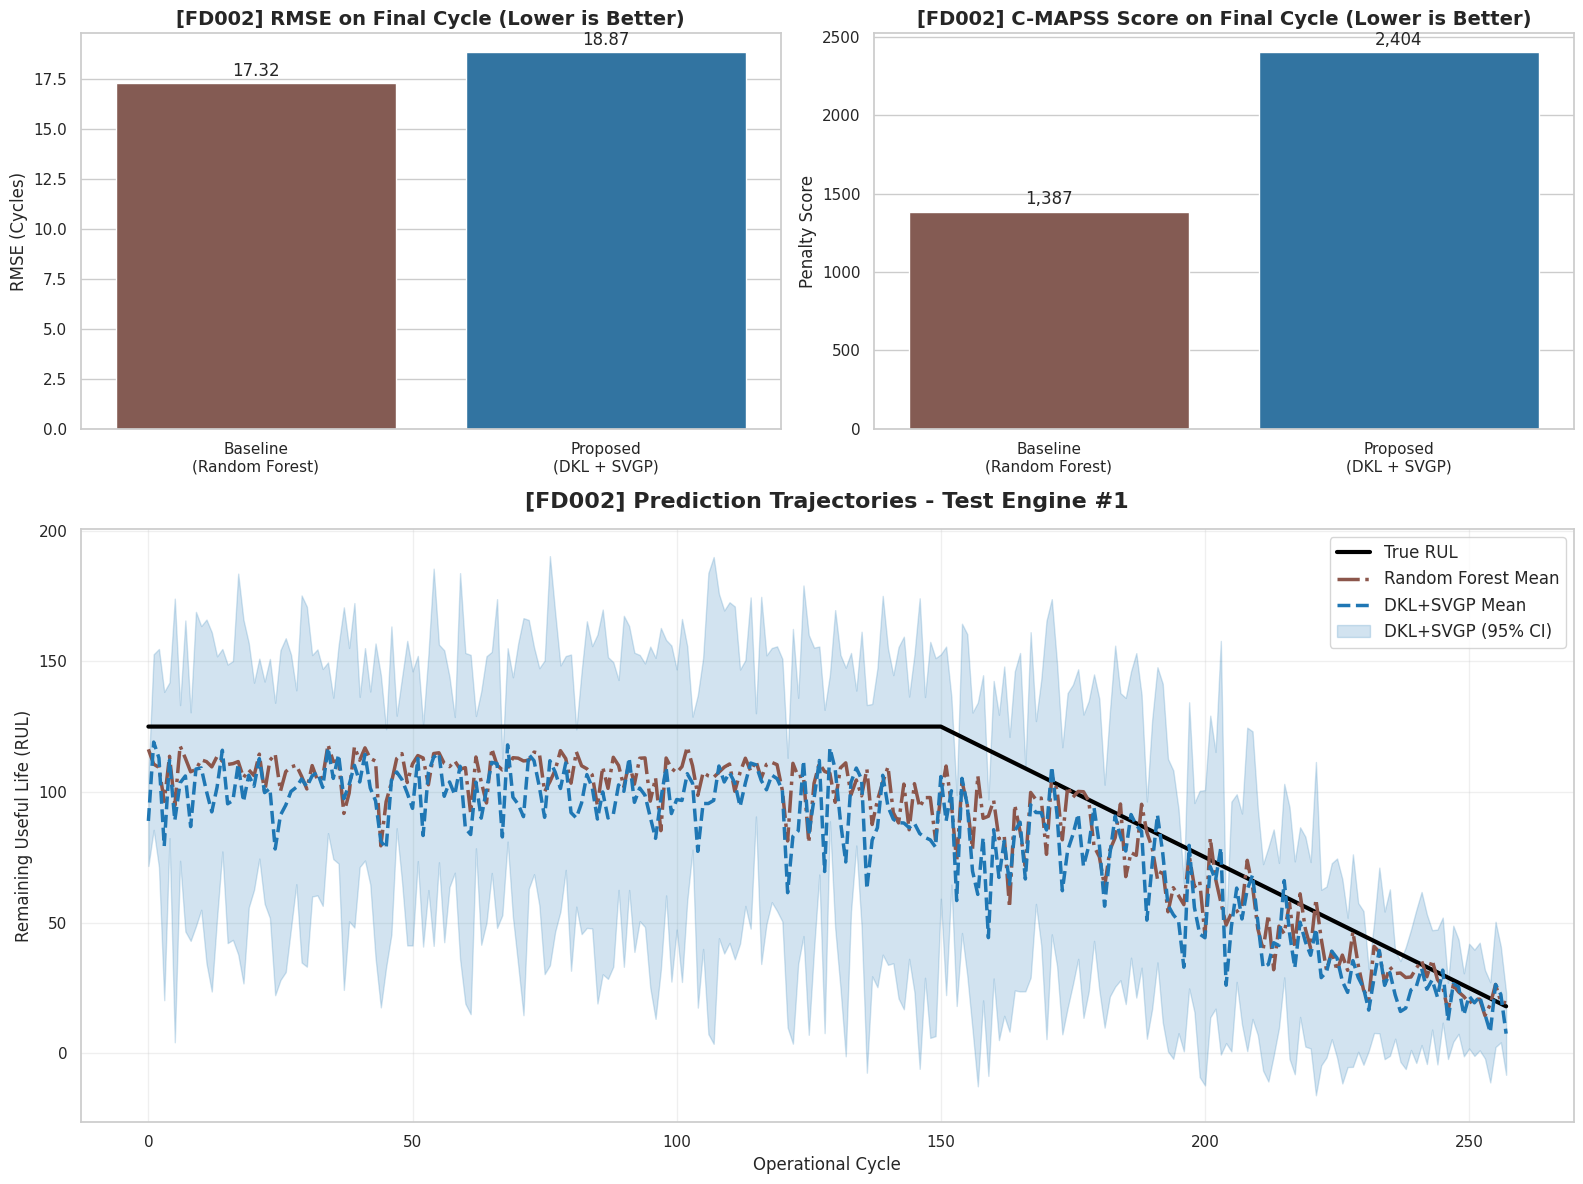



🚀 INIZIO VALUTAZIONE DATASET: FD003
Colonne escluse (Varianza 0): ['setting_3', 's_1', 's_18', 's_19']
Features attive (Settings + Sensori) fornite ai modelli: 20
🌲 Addestramento Baseline (Random Forest)...
🧠 Addestramento Proposed Model (DKL+SVGP - 100 epoche)...
--- Starting DKL Autoencoder SVGP Training (100 Epochs) ---
Epoch 01 | MLL Loss: 985228.4407 | Recon Loss: 0.9977
Epoch 02 | MLL Loss: 346906.2337 | Recon Loss: 0.7667
Epoch 03 | MLL Loss: 216183.9010 | Recon Loss: 0.6055
Epoch 04 | MLL Loss: 152402.2857 | Recon Loss: 0.5007
Epoch 05 | MLL Loss: 116698.6844 | Recon Loss: 0.4342
Epoch 06 | MLL Loss: 93353.8186 | Recon Loss: 0.3921
Epoch 07 | MLL Loss: 77482.2280 | Recon Loss: 0.3673
Epoch 08 | MLL Loss: 66138.0650 | Recon Loss: 0.3493
Epoch 09 | MLL Loss: 57521.1153 | Recon Loss: 0.3383
Epoch 10 | MLL Loss: 50357.7612 | Recon Loss: 0.3299
Epoch 11 | MLL Loss: 45049.1480 | Recon Loss: 0.3255
Epoch 12 | MLL Loss: 40392.4139 | Recon Loss: 0.3216
Epoch 13 | MLL Loss: 36758.3447 

/tmp/ipykernel_1246398/3016407815.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_labels, y=[rf_rmse, dkl_rmse], ax=ax_rmse, palette=palette)
/tmp/ipykernel_1246398/3016407815.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_labels, y=[rf_score, dkl_score], ax=ax_score, palette=palette)


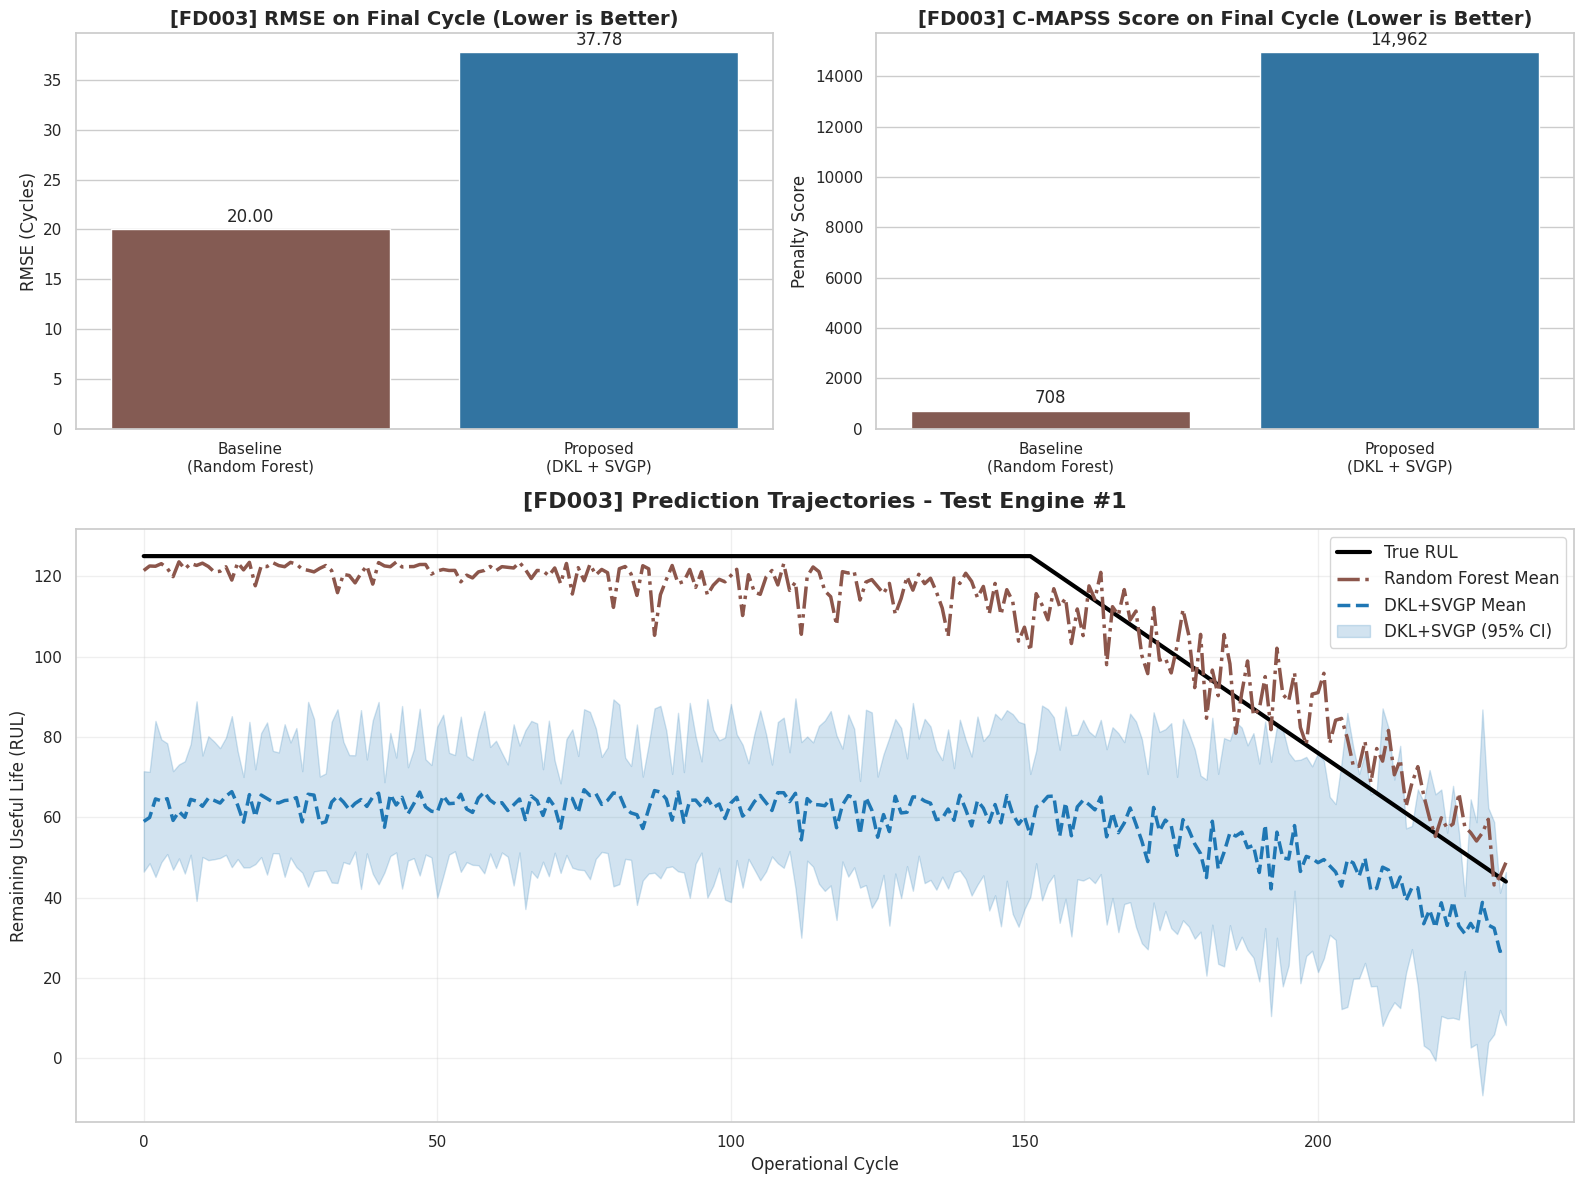



🚀 INIZIO VALUTAZIONE DATASET: FD004
Colonne escluse (Varianza 0): Nessuna
Features attive (Settings + Sensori) fornite ai modelli: 24
🌲 Addestramento Baseline (Random Forest)...
🧠 Addestramento Proposed Model (DKL+SVGP - 100 epoche)...
--- Starting DKL Autoencoder SVGP Training (100 Epochs) ---
Epoch 01 | MLL Loss: 1038637.4783 | Recon Loss: 0.6463
Epoch 02 | MLL Loss: 279261.9795 | Recon Loss: 0.2528
Epoch 03 | MLL Loss: 153818.4382 | Recon Loss: 0.1401
Epoch 04 | MLL Loss: 106678.0219 | Recon Loss: 0.0973
Epoch 05 | MLL Loss: 80268.2001 | Recon Loss: 0.0815
Epoch 06 | MLL Loss: 63114.6665 | Recon Loss: 0.0808
Epoch 07 | MLL Loss: 50251.9609 | Recon Loss: 0.0785
Epoch 08 | MLL Loss: 41929.8867 | Recon Loss: 0.0774
Epoch 09 | MLL Loss: 35341.7316 | Recon Loss: 0.0875
Epoch 10 | MLL Loss: 29430.3569 | Recon Loss: 0.0896
Epoch 11 | MLL Loss: 25422.4370 | Recon Loss: 0.1027
Epoch 12 | MLL Loss: 23257.5177 | Recon Loss: 0.1077
Epoch 13 | MLL Loss: 19657.9029 | Recon Loss: 0.1058
Epoch 14

/tmp/ipykernel_1246398/3016407815.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_labels, y=[rf_rmse, dkl_rmse], ax=ax_rmse, palette=palette)
/tmp/ipykernel_1246398/3016407815.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_labels, y=[rf_score, dkl_score], ax=ax_score, palette=palette)


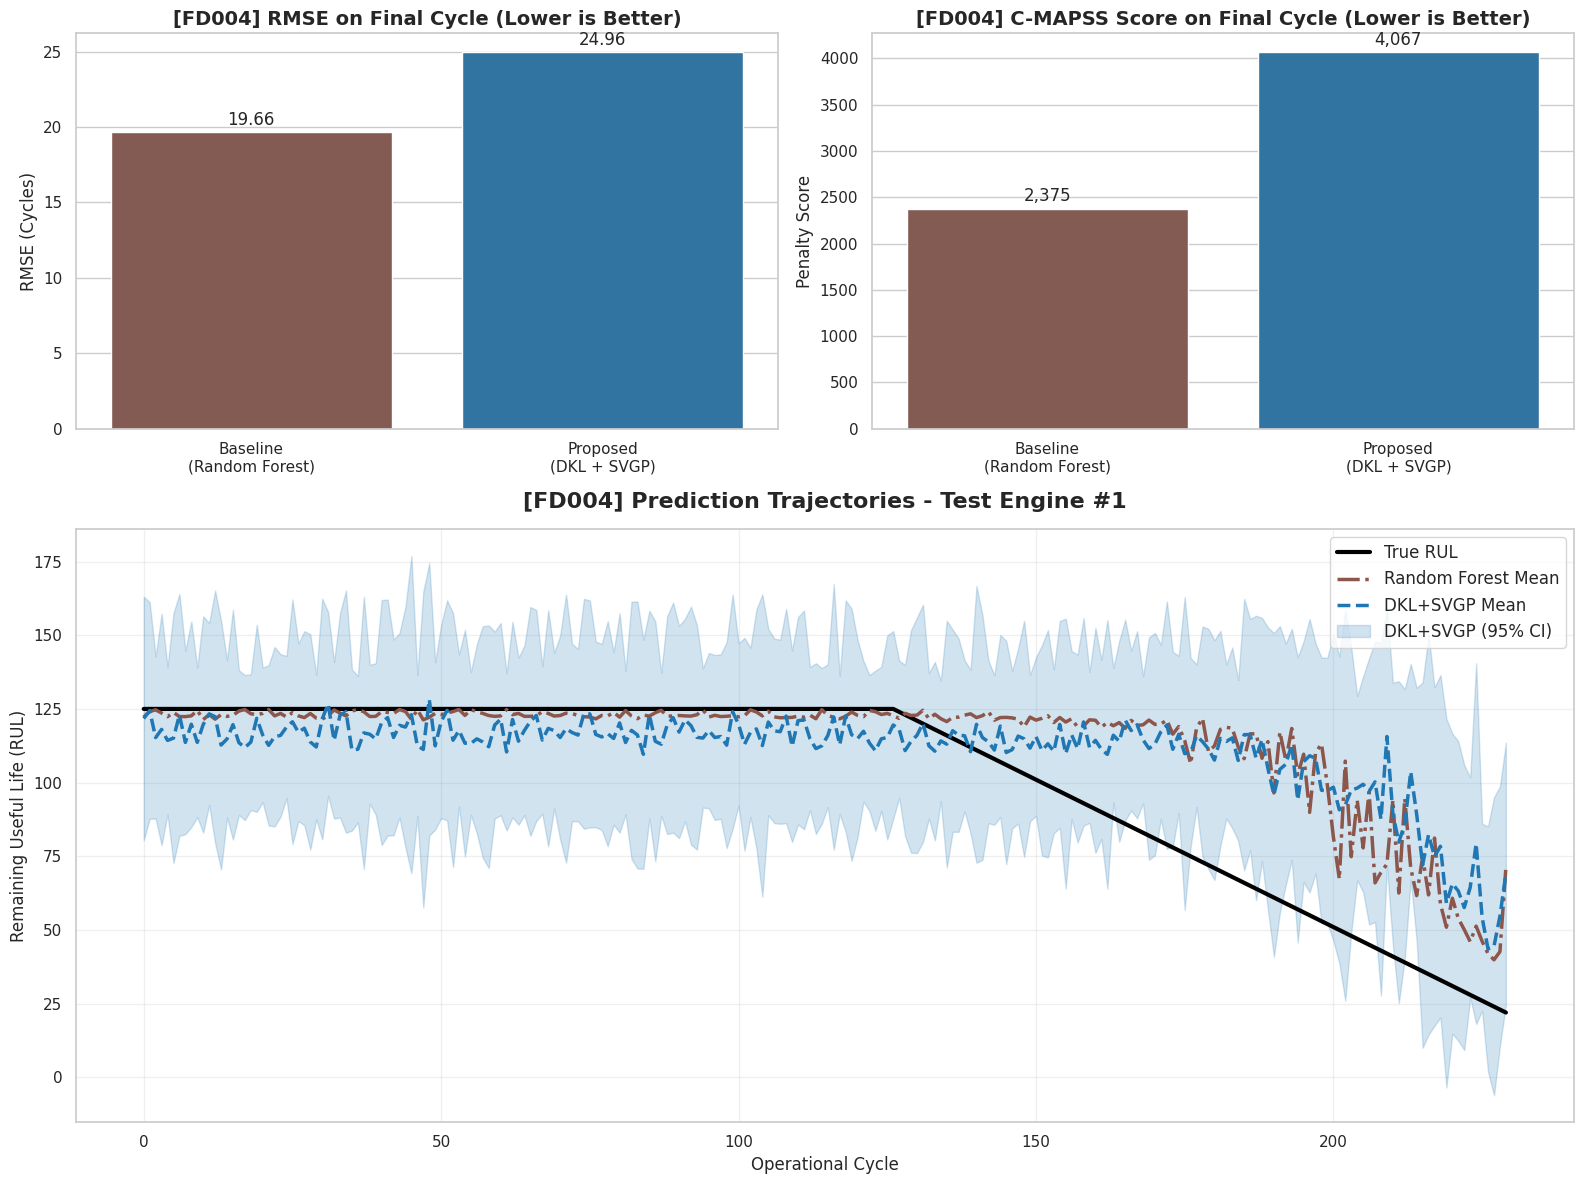


=== RIEPILOGO FINALE METRICHE ===
FD001 -> RF RMSE: 17.01 | DKL RMSE: 52.39
FD002 -> RF RMSE: 17.32 | DKL RMSE: 18.87
FD003 -> RF RMSE: 20.00 | DKL RMSE: 37.78
FD004 -> RF RMSE: 19.66 | DKL RMSE: 24.96


In [ ]:
global_results = {}

# Test FD001
global_results['FD001'] = compare_cmapss_dataset('FD001', dkl_epochs=100)

# Test FD002
global_results['FD002'] = compare_cmapss_dataset('FD002', dkl_epochs=100)

# Test FD003
global_results['FD003'] = compare_cmapss_dataset('FD003', dkl_epochs=100)

# Test FD004
global_results['FD004'] = compare_cmapss_dataset('FD004', dkl_epochs=100)


print("\n=== RIEPILOGO FINALE METRICHE ===")
for ds, metrics in global_results.items():
    print(f"{ds} -> RF RMSE: {metrics['rf_rmse']:.2f} | DKL RMSE: {metrics['dkl_rmse']:.2f}")